In [16]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

def plot_attention_heatmap(matrix, xticklabels, yticklabels, title:str, xlabel:str, ylabel:str, cmap="Blues"):
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        xticklabels=xticklabels,
        yticklabels=yticklabels,
        cmap=cmap,
        cbar=True
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()



## Embeddings vlookup for each token (token ID)
- For simplicity we have taken simple input text `The cat sat` with only `4` dimensions for each token embedding.
- Dimensions of each token depends on which embedding model you are using; for eg. `all-MiniLM-L6-v2` has `384` dimensions so this model will give you 384 vector values for each token.

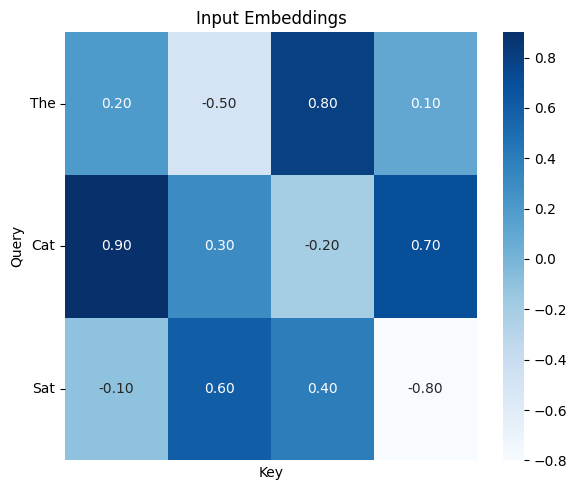

In [17]:
input_text = "The cat sat"

input_embeddings = np.matrix([
    [+0.20, -0.50, +0.80, +0.10], # The Embeddings
    [+0.90, +0.30, -0.20, +0.70], # Cat Embeddings
    [-0.10, +0.60, +0.40, -0.80]  # Sat Embeddings
])

tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=input_embeddings,
                       xticklabels=[], yticklabels=tokens, title="Input Embeddings", xlabel="Key", ylabel="Query")

## Weight matrix
- For computing self attention score we need 3 metrics
  1. Query weights
  2. Key weights
  3. Value weights
> Note: These metrics are learned parameter during training process

In [18]:
wq = np.matrix([
    [0.12,  0.31,  0.29, -0.49],
    [0.11,  1.44, -0.29, -0.11],
    [-0.10, -0.57, -0.08,  0.29],
    [0.08, -0.52,  0.54, -0.53]
]) # query weights

wk = np.matrix([
    [0.09, -0.02,  0.32, -0.42],
    [0.12,  1.34, -0.23, -0.16],
    [-0.13, -0.76, -0.12,  0.41],
    [0.07, -0.63,  0.55, -0.50]
]) # key weights

wv = np.matrix([
    [1.00,  0.00,  0.50,  0.10],
    [0.10,  1.00, -0.20,  0.30],
    [-0.50,  0.20,  1.00, -0.10],
    [0.20, -0.10,  0.00,  1.00]
]) # value weights

## Compute query, key and value metrics
- query: Represents current token / position that we are looking for
- key: Model compares query with these keys to determine how much `attention` or `weigths` should be placed on each position.
- value: These are the actual representation or information contained in each token. Once the model knows which key are most relevant to query, it extracts and sums the corresponding values.

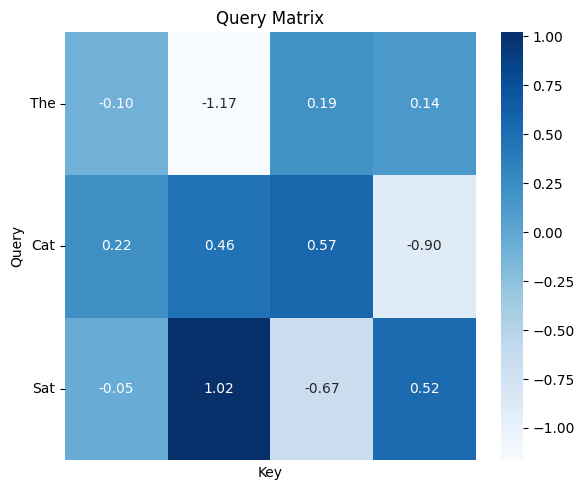

In [19]:
query = input_embeddings.dot(wq)
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=query,
                       xticklabels=[], yticklabels=tokens, title="Query Matrix", xlabel="Key", ylabel="Query")

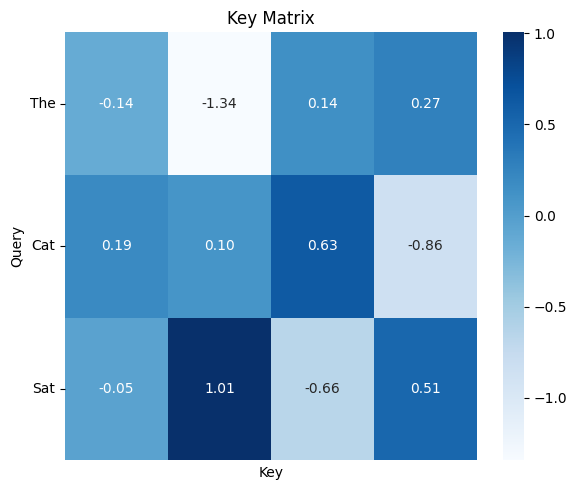

In [20]:
key = input_embeddings.dot(wk)
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=key,
                       xticklabels=[], yticklabels=tokens, title="Key Matrix", xlabel="Key", ylabel="Query")

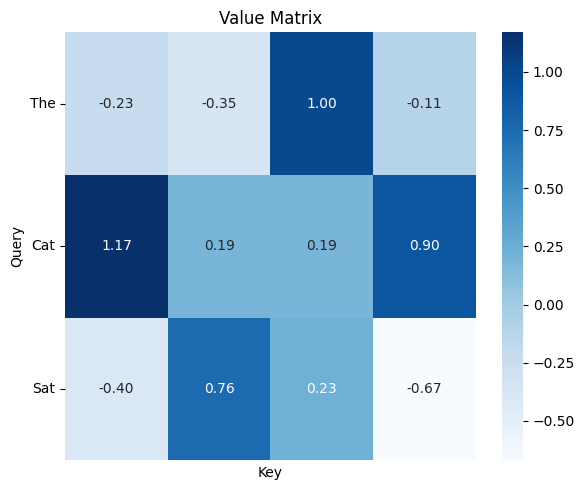

In [21]:
value = input_embeddings.dot(wv)
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=value,
                       xticklabels=[], yticklabels=tokens, title="Value Matrix", xlabel="Key", ylabel="Query")

## Attention Scores
row_attention_score = query * key_transpose

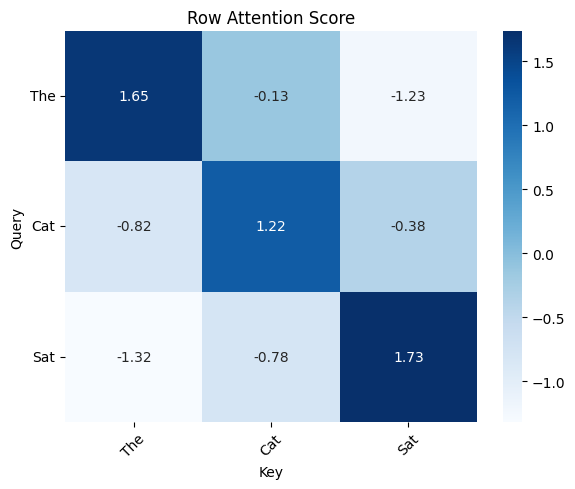

In [22]:
row_attention_score = query.dot(key.T)
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=row_attention_score,
                       xticklabels=tokens, yticklabels=tokens, title="Row Attention Score", xlabel="Key", ylabel="Query")

## Scale dot product attention scores

Why to scale attention score?
- In real life embedding dimensions are very large `(eg. 384 for all-MiniLM-L6-v2 )` leads to larger +ve and -ve scale of attention score.
- Softmax function will output saturated values due to larger variance in scores. So softmax will highlight some scores and neglect some scores completedly resulting burring important information.
- Eventually gradient dies and network stops learning.

This problem will be avoided by dividing by root dimensions

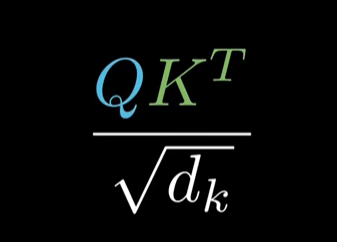 

- Here divider also called `variance stabilizer`

> Note: Only because of this division it is called scale dot product attention score.

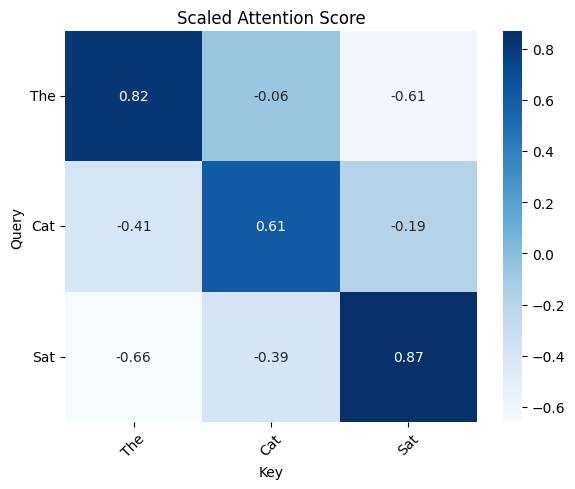

In [23]:
d_k = input_embeddings.shape[1]
scaled_attention_score = row_attention_score / np.sqrt(d_k)
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=scaled_attention_score,
                       xticklabels=tokens, yticklabels=tokens, title="Scaled Attention Score", xlabel="Key", ylabel="Query")

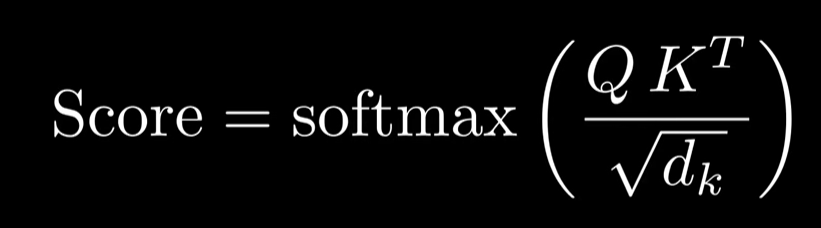

In [24]:
from scipy.special import softmax

prob_distributed_attention_scores = softmax(
    scaled_attention_score,
    axis=-1
)

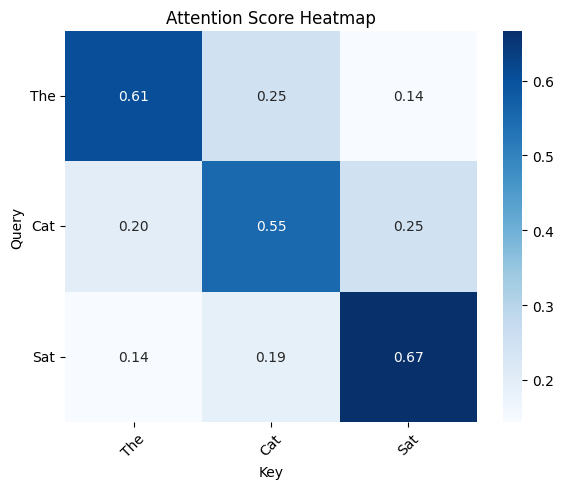

In [25]:
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=prob_distributed_attention_scores,
                       xticklabels=tokens, yticklabels=tokens, title="Attention Score Heatmap", xlabel="Key", ylabel="Query")

- Diagonal shows each word attend itself with high score which makes sense.
- Apart from the diagonal (cat, sat) shows attention score 25%.
- So from this attention score model can answer below question
   1. Who sat? --> cat

## The complete attention formula

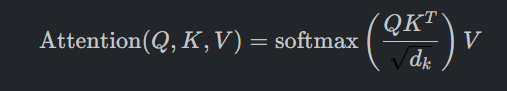

## Contribution of value vector


In [26]:
# weighted sum of values (query = "The")
expanded_scores = np.array([
    [prob_distributed_attention_scores[0][i]] * 4
    for i in range(3)
])
result = np.multiply(expanded_scores, np.array(value))
column_sums_the = result.sum(axis=0)
column_sums_the

array([ 0.09523584, -0.05511428,  0.68666968,  0.06159721])

In [27]:
# weighted sum of values (query = "Cat")
expanded_scores = np.array([
    [prob_distributed_attention_scores[1][i]] * 4
    for i in range(3)
])
result = np.multiply(expanded_scores, np.array(value))
column_sums_cat = result.sum(axis=0)
column_sums_cat

array([0.50071898, 0.22388938, 0.36150577, 0.30851136])

In [28]:
# weighted sum of values (query = "Sat")
expanded_scores = np.array([
    [prob_distributed_attention_scores[2][i]] * 4
    for i in range(3)
])
result = np.multiply(expanded_scores, np.array(value))
column_sums_sat = result.sum(axis=0)
column_sums_sat

array([-0.07815199,  0.49126553,  0.3339928 , -0.29164494])

## Updated final vectors with attention scores

In [29]:
attention_matrix = [
column_sums_the, column_sums_cat, column_sums_sat
]
attention_matrix

[array([ 0.09523584, -0.05511428,  0.68666968,  0.06159721]),
 array([0.50071898, 0.22388938, 0.36150577, 0.30851136]),
 array([-0.07815199,  0.49126553,  0.3339928 , -0.29164494])]

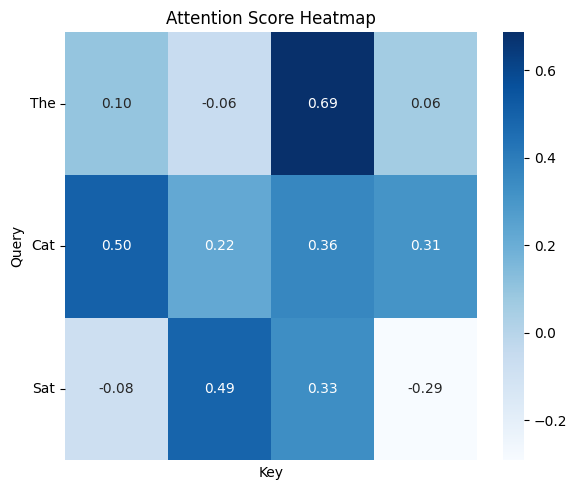

In [30]:
tokens = ["The", "Cat", "Sat"]
plot_attention_heatmap(matrix=attention_matrix,
                       xticklabels=[], yticklabels=tokens, title="Attention Score Heatmap", xlabel="Key", ylabel="Query")

## Summary:
1. Compute embeddings for input query - "The cat sat"
2. Compute query, key and value using respective weights
3. Compute row attention score = Q.Kt
4. Divide the attention score by variance stabilizer (root(dimensions)) to avoid gradient dies.
5. Compute weighted sum of values to get updated embeddings for the input query.